# 06b - Grad-CAM Check

Manual Grad-CAM on the baseline checkpoint (`checkpoints/baseline_best.pt`), val split only.
No pretrained models, no CAM library — hooks on `block4`. This is a visual check of where
the model is looking, not an accuracy check.

In [1]:
import os
import random

import cv2
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

from citrus_common import load_normalization_stats, get_transforms
from citrus_model import CitrusNet

## Seed and device

In [2]:
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Load model and checkpoint

State dict only, loaded onto a fresh `CitrusNet`.

In [3]:
model = CitrusNet(num_classes=4)
state_dict = torch.load("checkpoints/baseline_best.pt", map_location=device)
model.load_state_dict(state_dict)
model.eval()
model = model.to(device)

## Transform and class mapping

Val transform (no augmentation), same normalization stats as training.

In [4]:
mean, std = load_normalization_stats("normalization_stats.json")
val_transform = get_transforms(augment=False, mean=mean, std=std, size=224)

class_to_idx = {"aphids": 0, "gummosis": 1, "healthy": 2, "leaf_minnor": 3}
idx_to_class = {v: k for k, v in class_to_idx.items()}

## Grad-CAM

Forward hook on `block4` grabs the activations, backward hook grabs the gradients flowing
into them. `generate()` does its own forward and backward pass for the given input and
target class, so activations/gradients are always from the same pass.

In [5]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, target_class]
        score.backward()

        # one weight per channel: GAP the gradients over H, W
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))

        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        return cv2.resize(cam, (224, 224), interpolation=cv2.INTER_LINEAR)

## Prediction helper

Separate no-grad forward pass, just to get the predicted class and confidence.

In [6]:
def get_prediction(model, input_tensor):
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs[0, pred_class].item()
    return pred_class, confidence

## Pick val images

3 per class where available. Val split only, test is not touched here.

In [7]:
val_dir = "processed/224/val"
samples = []

for class_name in class_to_idx:
    class_dir = os.path.join(val_dir, class_name)
    files = sorted(f for f in os.listdir(class_dir) if f.lower().endswith(".jpg"))
    chosen = random.sample(files, min(3, len(files)))
    samples.extend((os.path.join(class_dir, f), class_name) for f in chosen)

len(samples)

12

## Overlay helper

Heatmap at ~40% opacity over the original image.

In [8]:
def make_overlay(original_rgb, cam):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(original_rgb, 0.6, heatmap, 0.4, 0)

## Run Grad-CAM on each sample

Original image is loaded and resized with plain PIL, separately from the model's input
tensor which goes through the actual val transform.

In [9]:
gradcam = GradCAM(model, model.block4)
results = []

for path, true_class in samples:
    img = Image.open(path).convert("RGB")
    display_img = np.array(img.resize((224, 224)))

    input_tensor = val_transform(img).unsqueeze(0).to(device)
    pred_class, confidence = get_prediction(model, input_tensor)
    cam = gradcam.generate(input_tensor, pred_class)
    overlay = make_overlay(display_img, cam)

    results.append({
        "original": display_img,
        "overlay": overlay,
        "true": true_class,
        "pred": idx_to_class[pred_class],
        "confidence": confidence,
    })

len(results)

12

## Grid

One row per class, original next to overlay for each sample.

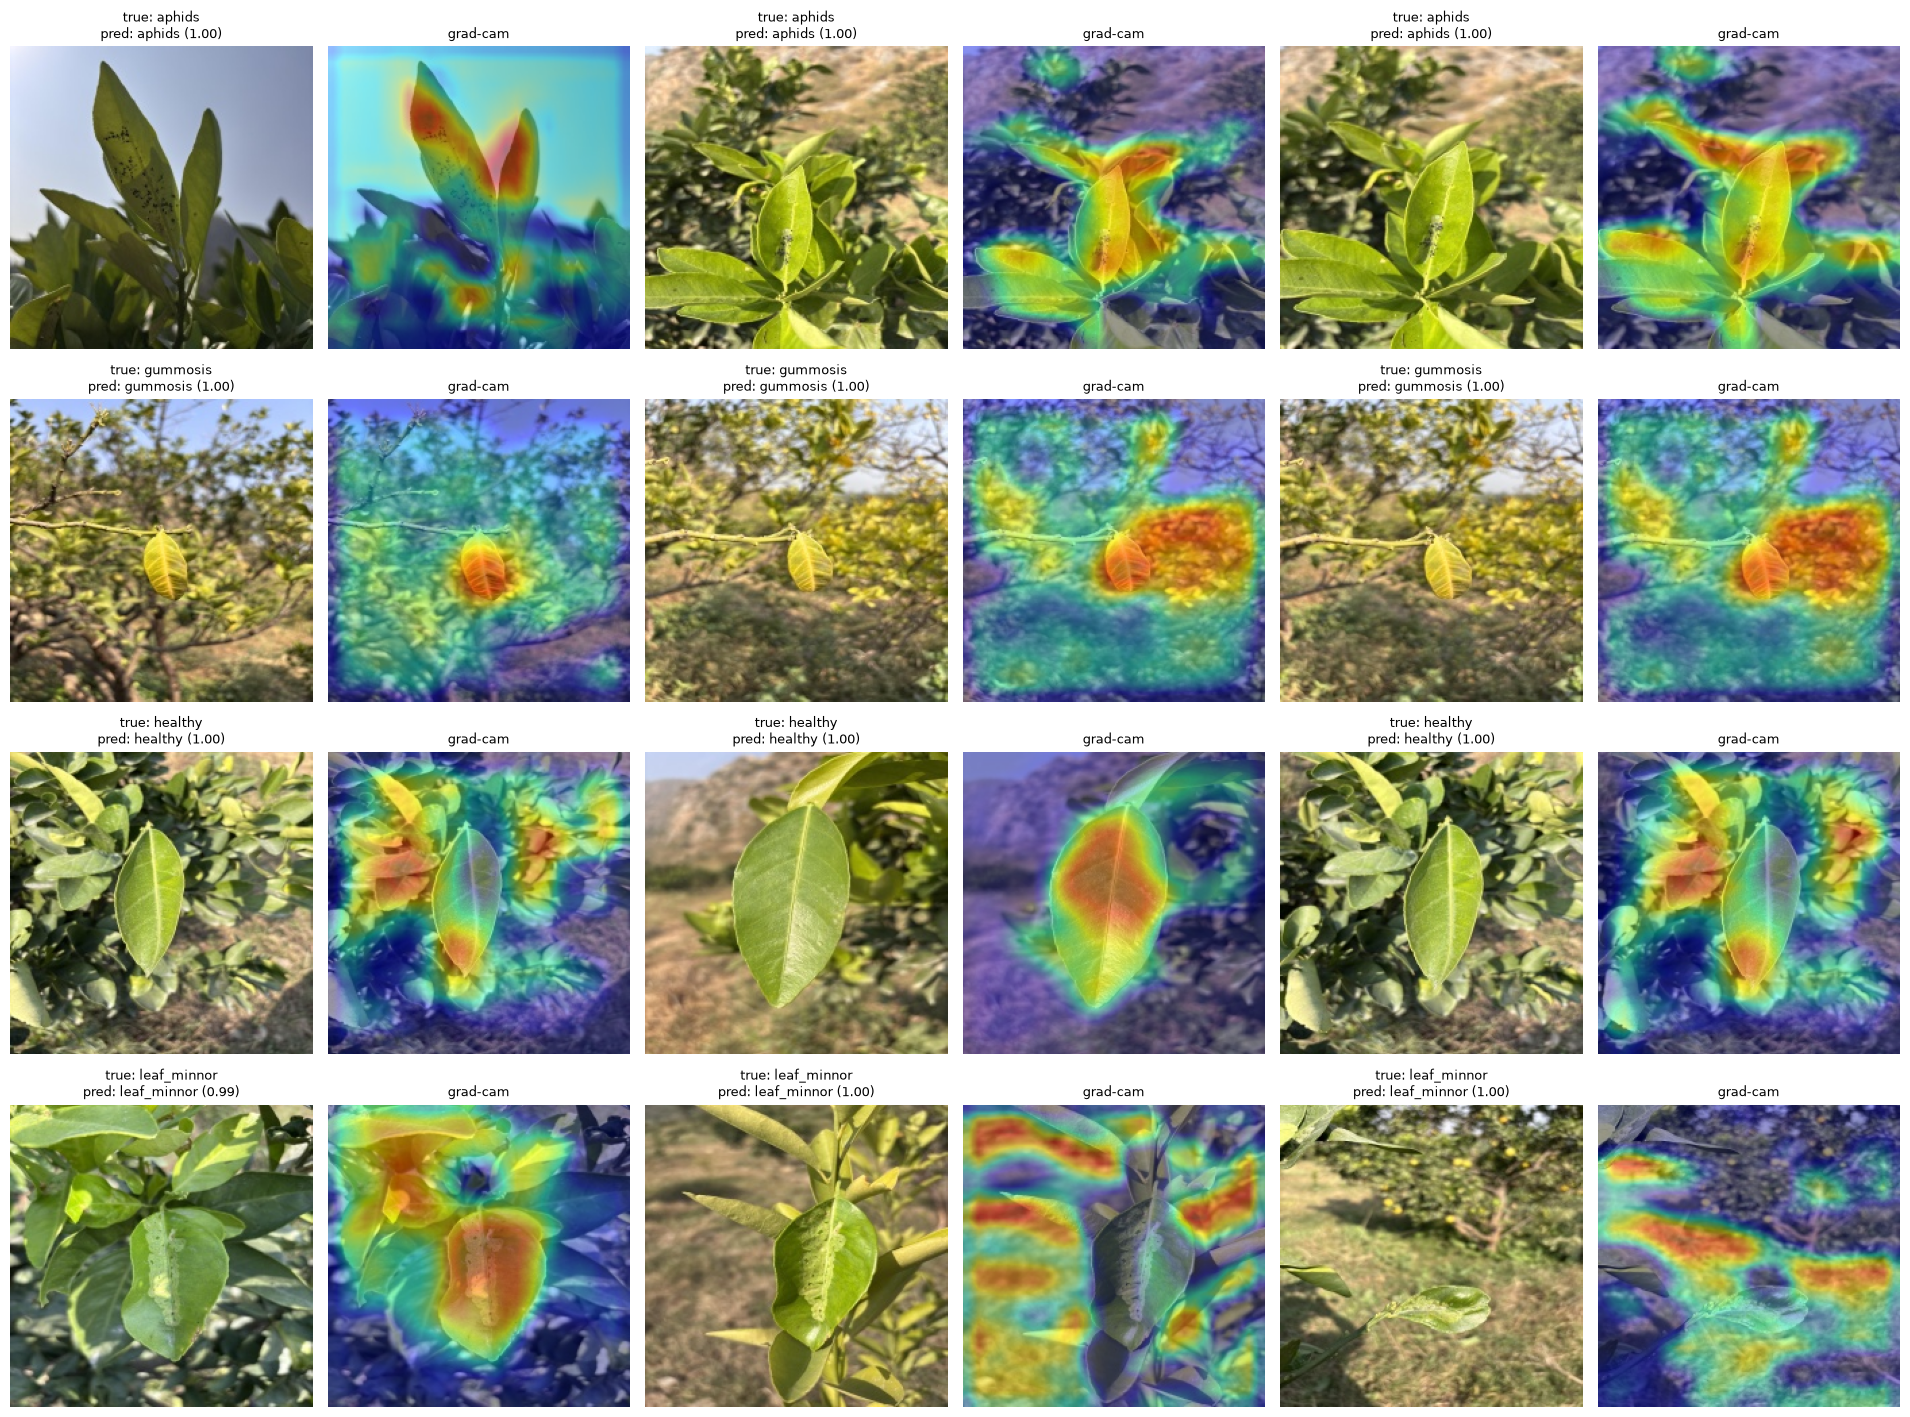

In [10]:
n_classes = len(class_to_idx)
max_per_class = 3

fig, axes = plt.subplots(
    n_classes, max_per_class * 2,
    figsize=(3.2 * max_per_class * 2, 3.6 * n_classes),
)

for row, class_name in enumerate(class_to_idx):
    class_results = [r for r in results if r["true"] == class_name]
    for i in range(max_per_class):
        ax_orig = axes[row, i * 2]
        ax_cam = axes[row, i * 2 + 1]
        ax_orig.axis("off")
        ax_cam.axis("off")
        if i < len(class_results):
            r = class_results[i]
            ax_orig.imshow(r["original"])
            ax_orig.set_title(f"true: {r['true']}\npred: {r['pred']} ({r['confidence']:.2f})", fontsize=9)
            ax_cam.imshow(r["overlay"])
            ax_cam.set_title("grad-cam", fontsize=9)

plt.tight_layout()
plt.show()

Check whether the highlighted regions fall on the actual leaf and its symptoms (insect
clusters, gum patches, mining trails) versus on background elements like branches, soil,
or sky. That's the thing to visually judge from this grid before trusting the accuracy
numbers.